```{toctree}
:maxdepth: 3
:caption: Contents:

# Walkthrough Example

General workflow of oceanicospy library for new users

## Importing libraries

In [1]:
#import general libraries used on several sections
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import glob
from pathlib import Path

## Observations

In [2]:
#import libraries used for observation reading
from oceanicospy.observations import pressure_sensors,weather_stations,AWAC,\
                                    WaveBuoy,ctd,HOBO_Temp,HOBO_TempCond

### Pressure sensors: AQuaLogger and RBR

Process two pressure sensor observation from San Andrés Island from 2025, an AQuaLogger and an RBR

In [3]:
measurement_pressure_sensors_paths = ['../data/oceanicospy-example/observations/AQ/',
                                      '../data/oceanicospy-example/observations/RBR/SV28-1_0525/']

sampling_AQ = dict(anchoring_depth=9.5, sensor_height=0.2, sampling_freq=1,burst_length_s=2048,
                    start_time=datetime(2025,5,12,0,0,0),
                    end_time=datetime(2025,5,17,23,0,0))
sampling_RBR = dict(anchoring_depth=8, sensor_height=0.2, sampling_freq=1, burst_length_s=3600,
                    start_time=datetime(2025,5,22,0,0,0),
                    end_time=datetime(2025,5,27,23,0,0))

In [4]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict() 

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    print(measurement_path)
    if 'AQ' in measurement_path:
        object_device = pressure_sensors.AQUAlogger(measurement_path, sampling_data[idx],
                                                    filename='SV27_0525.csv')
    elif 'Bluelog' in measurement_path:
        object_device = pressure_sensors.Bluelog(measurement_path, sampling_data[idx])
    else:
        object_device = pressure_sensors.RBR(measurement_path,sampling_data[idx])
    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

../data/oceanicospy-example/observations/AQ/
../data/oceanicospy-example/observations/RBR/SV28-1_0525/


In [5]:
dict_clean_measurements['AQ'].head()

,pressure[bar],depth[m],depth_aux[m],burstId,eta[m]
date,,,,,
2025-05-12 01:00:00,1.853331,9.701095,8.337958,1,0.000985
2025-05-12 01:00:01,1.852619,9.693552,8.330892,1,-0.006553
2025-05-12 01:00:02,1.852762,9.695061,8.332311,1,-0.005039
2025-05-12 01:00:03,1.852477,9.692044,8.329482,1,-0.008051
2025-05-12 01:00:04,1.851907,9.686010,8.323825,1,-0.014079


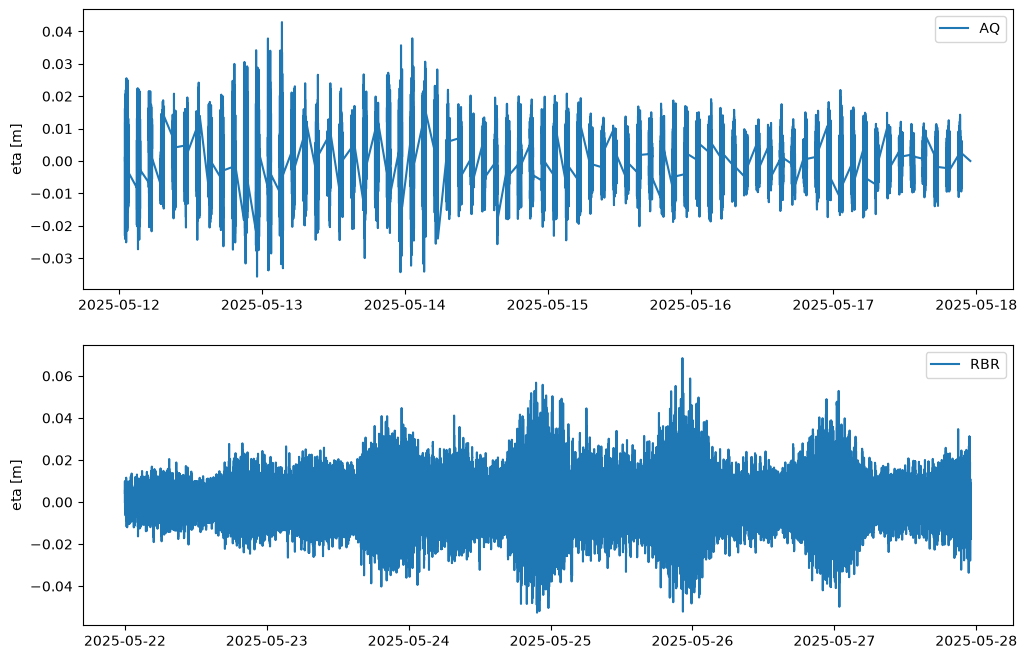

In [6]:
fig, ax = plt.subplots(2,1,figsize=(12,8),sharex=False)
for idx,metadata in enumerate(metadata_list):
    ax[idx].plot(dict_clean_measurements[metadata].index,dict_clean_measurements[metadata]['eta[m]'],label=metadata)
    ax[idx].set_ylabel('eta [m]')
    ax[idx].legend()

## Analysis

Now, previois processed observations will be analyzed for wave params estimation by temporal and spectral methods

### Import libraries

In [7]:
from oceanicospy.analysis import temporal
from oceanicospy.analysis import spectral
from oceanicospy.plots import *

### Temporal wave parameters estimation

In [8]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],
                                                     sampling_data[idx])
    print(f"The {metadata} sensor data is being analyzed using {type(TemporalAnalyzer)}")
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

The AQ sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [72]
The RBR sensor data is being analyzed using <class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
The following bursts have been removed due to incorrect length: [144]


In [9]:
#Quick check on dataframes
wave_params_dfs['AQ'].head()

,H1/3,Tmean
time,,
2025-05-12 01:00:00,0.137625,13.127994
2025-05-12 03:00:00,0.149663,12.474390
2025-05-12 05:00:00,0.109776,12.132015
2025-05-12 07:00:00,0.124505,10.327230
2025-05-12 09:00:00,0.124143,13.018086


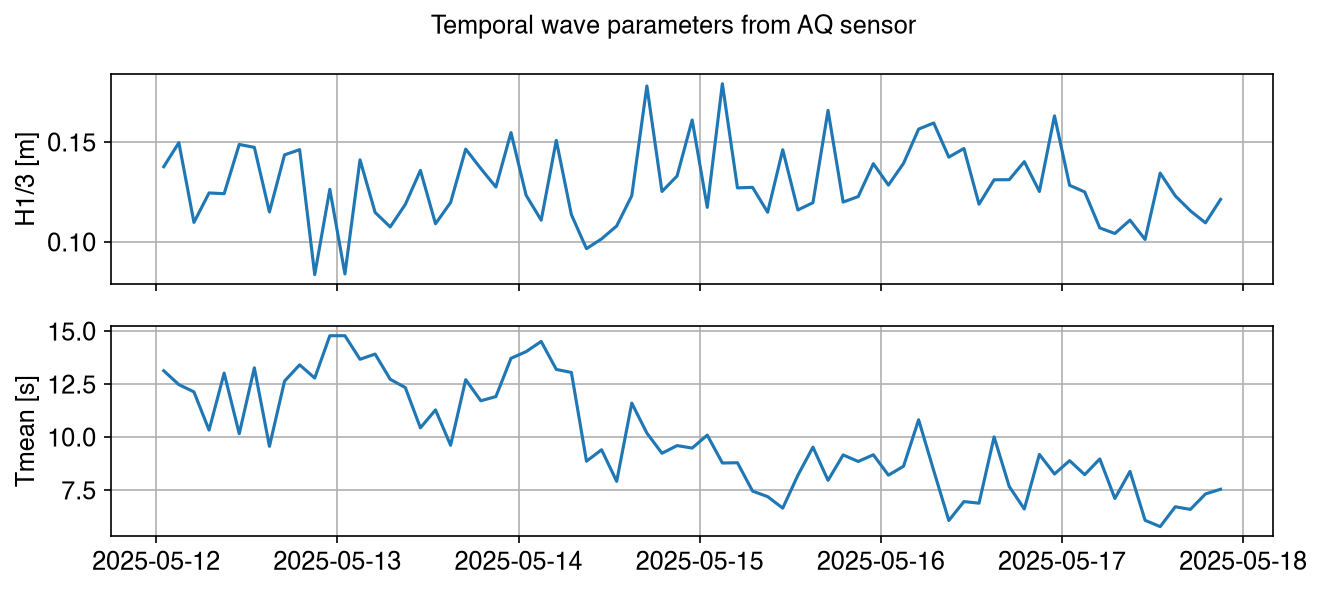

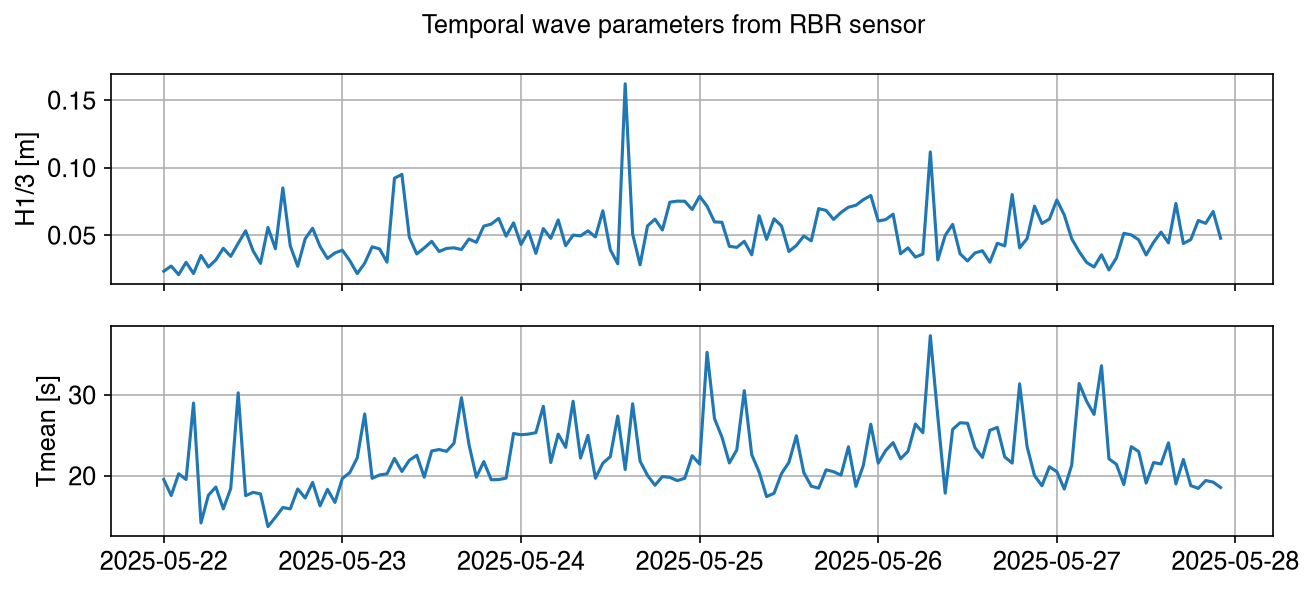

In [10]:
for idx,metadata in enumerate(metadata_list):
    fig, ax = plt.subplots(2,1,figsize=(10,4),sharex=True)
    ax[0].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['H1/3'],label=metadata)
    ax[0].set_ylabel('H1/3 [m]')
    ax[0].grid()

    ax[1].plot(wave_params_dfs[metadata].index,wave_params_dfs[metadata]['Tmean'],label=metadata)
    ax[1].set_ylabel('Tmean [s]')
    ax[1].grid()

    fig.suptitle(f"Temporal wave parameters from {metadata} sensor")
    plt.show()

### Spectral wave parameters estimation

In [11]:
dict_spectra_welch = dict()
dict_integral_params_welch = dict()
dict_spectra_fft = dict()
dict_integral_params_fft = dict()

for idx,metadata in enumerate(metadata_list):
    SpectralAnalyzer = spectral.WaveSpectralAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(SpectralAnalyzer))

    spectra_welch,params_welch = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='welch',
                                                                                    kp_correction=False,
                                                                                    ig_split=True,
                                                                                    freq_split=0.04, 
                                                                                    window_type='hamming',
                                                                                    window_length=1024,
                                                                                    overlap=512,
                                                                                    smoothing_bins=6)
    spectra_fft,params_fft = SpectralAnalyzer.get_spectra_and_params_for_bursts(method='fft',
                                                                                kp_correction=False,
                                                                                ig_split=True,
                                                                                freq_split=0.04)

    dict_spectra_welch[metadata_list[idx]] = spectra_welch
    dict_integral_params_welch[metadata_list[idx]] = params_welch
    dict_spectra_fft[metadata_list[idx]] = spectra_fft
    dict_integral_params_fft[metadata_list[idx]] = params_fft

<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>
<class 'oceanicospy.analysis.spectral.WaveSpectralAnalyzer'>


In [12]:
dict_integral_params_welch['AQ'].head()

,Hm0,Hrms,Hmean,Tp,Tm01,Tm02,time,Hm0_ig,Hm0_sw
date,,,,,,,,,
2025-05-12 01:00:00,0.036068,0.025479,0.022580,204.800000,26.855341,13.001155,2025-05-12 01:00:00,0.031699,0.015324
2025-05-12 03:00:00,0.033713,0.023815,0.021105,256.000000,27.786927,12.277584,2025-05-12 03:00:00,0.030180,0.012957
2025-05-12 05:00:00,0.025474,0.017995,0.015947,256.000000,24.934993,10.655178,2025-05-12 05:00:00,0.022562,0.009868
2025-05-12 07:00:00,0.022511,0.015901,0.014092,256.000000,22.428117,9.615137,2025-05-12 07:00:00,0.020155,0.007773
2025-05-12 09:00:00,0.026564,0.018765,0.016630,341.333333,30.557403,11.458326,2025-05-12 09:00:00,0.024427,0.008229


In [13]:
dict_spectra_welch['AQ'].keys()

dict_keys(['S', 'dir', 'freq', 'time'])

Text(0.5, 0.98, 'Comparison of Welch and FFT methods for AQ sensor')

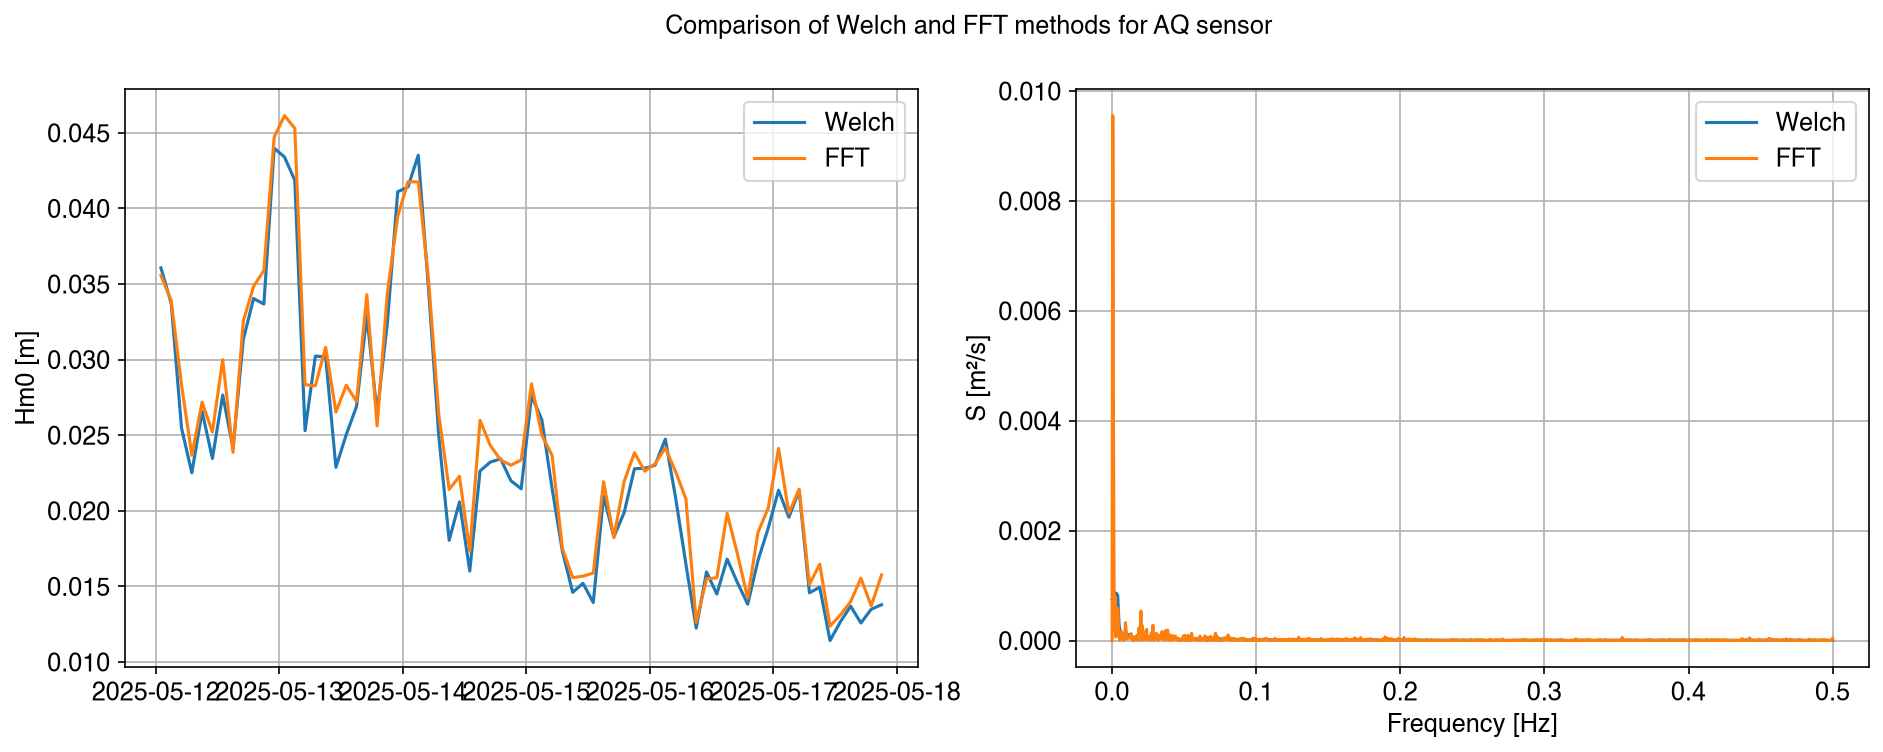

In [14]:
fig, ax = plt.subplots(1,2,figsize=(15,5),sharex=False)
ax[0].plot(dict_integral_params_welch['AQ'].index,dict_integral_params_welch['AQ']['Hm0'],label='Welch')
ax[0].plot(dict_integral_params_fft['AQ'].index,dict_integral_params_fft['AQ']['Hm0'],label='FFT')
ax[0].set_ylabel('Hm0 [m]')
ax[0].grid()
ax[0].legend()

ax[1].plot(dict_spectra_welch['AQ']['freq'],dict_spectra_welch['AQ']['S'][-1],label='Welch')
ax[1].plot(dict_spectra_fft['AQ']['freq'],dict_spectra_fft['AQ']['S'][-1],label='FFT')
ax[1].set_ylabel('S [m²/s]'); ax[1].set_xlabel('Frequency [Hz]')
ax[1].grid()
ax[1].legend()
fig.suptitle('Comparison of Welch and FFT methods for AQ sensor')


## GIS

### Import libraries

In [2]:
import pandas as pd
import geopandas as gpd

from oceanicospy.gis import (
    XYZFormatSpec,
    PointFileIO,
    PointFileReprojector,
    reproject_points,
    XYZMerger,
    AxisAlignedRectangle,
    XYZRectangleMask,
    ProfileAxis,
    ProfileInterpolator,
    Grid
)

### Read and reproject from xyz file

In [55]:
xyz_input_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_50m/bat_sai_50m.txt"
xyz_output_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_9377_from_xyz.xyz"

reproject_points(
    input_path=xyz_input_path,
    output_path=xyz_output_path,
    target_epsg=9377,
    source_epsg=4326,
)

### Read and reproject from shp files

In [47]:
shp_path = "../data/oceanicospy-example/gis/bathymetries/raw/SAI_200m/bat_sai_200m.shp"
preview = PointFileIO(shp_path)
df_preview = preview.read()
print(df_preview.columns.tolist())
print(preview.read_as_geodataframe().crs)

['X', 'Field2', 'Y', 'Field4', 'Z', 'x', 'y']
EPSG:4326


In [48]:
vector_reprojected_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_200m_9377_from_shp.xyz"

reproject_points(
    input_path=shp_path,
    output_path=vector_reprojected_path,
    target_epsg=9377,
    z_column="Z",
)

### Merging files

In [3]:
tiles_dir = "../data/oceanicospy-example/gis/bathymetries/processed/"
merged_path = "../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz"

priority = [
    "MDE_SAI_2m_2020_ColenMapas_EPSG9377.xyz",  # highest priority
    "bat_sai_50m_9377_from_xyz.xyz",   
    "bat_sai_200m_9377_from_shp.xyz",  # lowest priority
]

merger = XYZMerger(
    input_dir=tiles_dir,
    priority=priority,
    crs=9377,
)

In [4]:
df_merged = merger.run_merge(merged_path)
df_merged.head()

,x,y,z
0,4070045.441,2940105.090,1909.419
1,4069847.849,2940111.440,1926.113
2,4069650.255,2940117.792,1932.791
3,4069452.661,2940124.146,1897.840
4,4069255.066,2940130.501,1915.992


In [ ]:
plt.tricontourf(df_merged['x'], df_merged['y'], df_merged['z'], levels=20, cmap='Blues_r')

## Models

### SWAN 2D

#### Import libraries

In [3]:
from oceanicospy.models.swanpy import Initializer
from oceanicospy.models.swanpy.preprocess import *
from oceanicospy.models.swanpy.execution import CaseRunner
from oceanicospy.models.swanpy.postprocess import SwanOutputReader
from oceanicospy.plots import *

#### Case configuration

In [4]:
domains = {
    1: {
        "grid": dict(lon_ll_corner=278.2, lat_ll_corner=12.4, x_extent=0.2, y_extent=0.3, nx=222, ny=333),
        "bathy": dict(lon_ll_corner_bot=278.1811, lat_ll_corner_bot=12.372, nx_bot=322, ny_bot=422, dx_bot=0.0009, dy_bot=0.0009),
        "fric": dict(lon_ll_corner_fric=278.1811, lat_ll_corner_fric=12.372, nx_fric=322, ny_fric=422, dx_fric=0.0009, dy_fric=0.0009),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.1811, lat_ll_corner_wl=12.372, nx_wl=322, ny_wl=422, dx_wl=0.0009, dy_wl=0.0009),
        "parent": None
    },
    2: {
        "grid": dict(lon_ll_corner=278.2265167, lat_ll_corner=12.4413166, x_extent=0.13185, y_extent=0.1908, nx=293, ny=424),
        "bathy": dict(lon_ll_corner_bot=278.2265167, lat_ll_corner_bot=12.4413166, nx_bot=293, ny_bot=424, dx_bot=0.00045, dy_bot=0.00045),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.2265167, lat_ll_corner_wl=12.4413166, nx_wl=293, ny_wl=424, dx_wl=0.00045, dy_wl=0.00045),
        "fric": dict(lon_ll_corner_fric=278.2265167, lat_ll_corner_fric=12.4413166, nx_fric=293, ny_fric=424, dx_fric=0.00045, dy_fric=0.00045),
        "parent": 1
    },
    3: {
        "grid": dict(lon_ll_corner=278.270165, lat_ll_corner=12.550217, x_extent=0.0747, y_extent=0.0747, nx=332, ny=332),
        "bathy": dict(lon_ll_corner_bot=278.270165, lat_ll_corner_bot=12.550217, nx_bot=332, ny_bot=332, dx_bot=0.000225, dy_bot=0.000225),
        "wind": dict(lon_ll_corner_wind=278, lat_ll_corner_wind=12.3, nx_wind=24, ny_wind=24, dx_wind=0.025, dy_wind=0.025),
        "wl":   dict(lon_ll_corner_wl=278.270165, lat_ll_corner_wl=12.550217, nx_wl=332, ny_wl=332, dx_wl=0.000225, dy_wl=0.000225),
        "fric": dict(lon_ll_corner_fric=278.270165, lat_ll_corner_fric=12.550217, nx_fric=332, ny_fric=332, dx_fric=0.000225, dy_fric=0.000225),
        "parent": 2
    }}

In [5]:
path_case = '../data/oceanicospy-example/model_runs/nonstationary_swan/'

ini_date = datetime(2025, 5, 10, 0)
end_date = datetime(2025, 5, 17, 23)

dict_ini_data = dict(
    name             = 'Non-stationary',
    case_number      = 1,
    case_description = 'Example non-stationary case for San Andres',
    stat_id          = 0, # 0 → non-stationary
    number_domains   = len(domains),
    parent_domains   = {d:cfg["parent"] for d, cfg in domains.items()})

#### Initializer

In [6]:
case = Initializer(
    root_path     = path_case,
    dict_ini_data = dict_ini_data,
    ini_date      = ini_date,
    end_date      = end_date,
)

case.create_folders()       # creates all project folders
case.replace_ini_data()     # writes run.swn from the NONSTAT template

*** Initializing SWAN model ***


	*** Creating project folder structure ***


	*** Copying base SWAN configuration file into run folder ***



#### Configure grid

In [7]:
for domain_id,config in domains.items():
    domain_grid_dict = config["grid"]
    case_grid = GridMaker(init = case,
                          domain_number = domain_id, 
                          grid_info = domain_grid_dict)
    case_grid.fill_grid_section()


*** Initializing gridmaker for domain 1 ***


 	*** Adding/Editing grid information for domain 1 in configuration file ***


*** Initializing gridmaker for domain 2 ***


 	*** Adding/Editing grid information for domain 2 in configuration file ***


*** Initializing gridmaker for domain 3 ***


 	*** Adding/Editing grid information for domain 3 in configuration file ***



#### Configure bathymetry

In [16]:
# Create a regular target grid
merged_path='../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz'
reader_geo = PointFileIO(merged_path, crs=9377)
gdf = reader_geo.read_as_geodataframe()
gdf = gdf.to_crs(epsg=4326)  # Reproject to WGS84 for consistency
gdf = gdf[gdf != -9999]  # Filter out invalid depth values

In [17]:
from scipy.interpolate import griddata

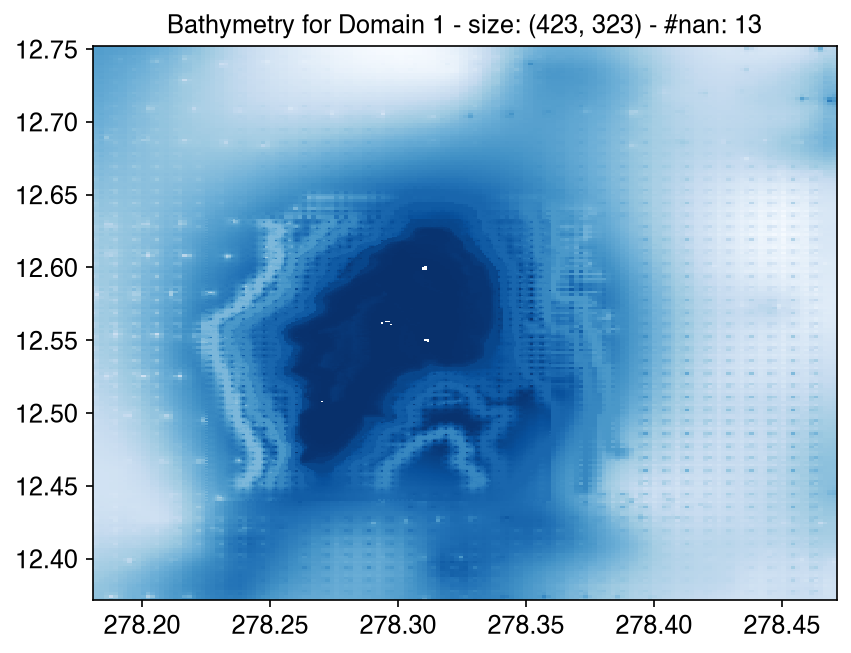

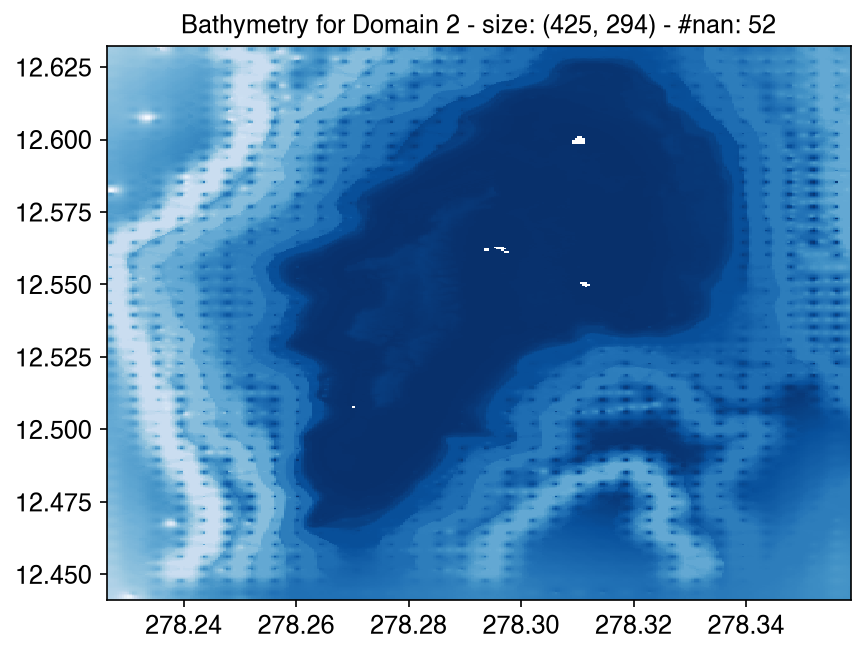

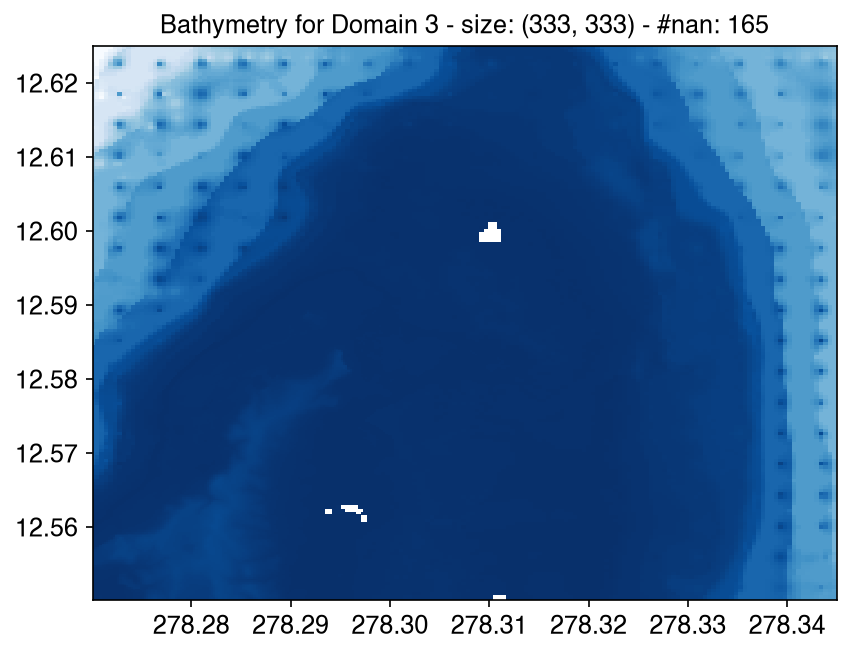

In [41]:
for d in list(domains.keys()):
    d_info=domains[d]['bathy']
    grid_x, grid_y = np.meshgrid(np.linspace(d_info['lon_ll_corner_bot'], d_info['lon_ll_corner_bot']+d_info['nx_bot']*d_info['dx_bot'], d_info['nx_bot']+1),
                                  np.linspace(d_info['lat_ll_corner_bot'], d_info['lat_ll_corner_bot']+d_info['ny_bot']*d_info['dy_bot'], d_info['ny_bot']+1))

    # Run the interpolation
    grid_z = griddata((gdf['geometry'].x.values+360, gdf['geometry'].y.values), gdf['z'].values, (grid_x, grid_y), method='nearest')
    grid_z2 = grid_z.copy()
    grid_z2[np.isnan(grid_z2)] = -9999  # Replace invalid values with NaN for better handling
    np.savetxt(f'{path_case}input/domain_0{d}/bot{d}.bot', grid_z2, delimiter=' ', fmt='%.4f')
    plt.pcolormesh(grid_x, grid_y, grid_z, shading='auto', cmap='Blues_r')
    plt.title(f"Bathymetry for Domain {d} - size: {grid_z.shape} - #nan: {np.isnan(grid_z).sum()}")
    plt.show()

In [8]:
for domain_id,config in domains.items():
    domain_bathy_dict = config["bathy"]
    case_bathy = BathyMaker(init = case,
                          domain_number = domain_id, 
                          bathy_info = domain_bathy_dict)
    case_bathy.use_ascii_file_from_user()
    case_bathy.fill_bathy_section()


*** Initializing bathymaker for domain 1 ***


 	*** Adding/Editing bathymetry information for domain 1 in configuration file ***


*** Initializing bathymaker for domain 2 ***


 	*** Adding/Editing bathymetry information for domain 2 in configuration file ***


*** Initializing bathymaker for domain 3 ***


 	*** Adding/Editing bathymetry information for domain 3 in configuration file ***



#### Configure boundary conditions

##### Wind

In [9]:
for domain_id,config in domains.items():
    domain_wind_dict = config["wind"]
    case_wind = WindForcing(init = case,
                          domain_number = domain_id, 
                          wind_info = domain_wind_dict)
    
    # Skips download if the file already exists in input/domain_01/
    case_wind.get_winds_from_ERA5(utc_offset_hours=-5, format_localtime=True)

    # Convert localtime NetCDF → SWAN ASCII and link into run/domain_01/
    case_wind.write_ERA5_ascii('winds_era5_localtime.nc', 'winds.wnd')
    case_wind.fill_wind_section()


*** Initializing winds for domain 1 ***

the file ../data/oceanicospy-example/model_runs/nonstationary_swan/input/domain_01/winds_era5.nc already exists
	 ERA5 wind data already exists, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd

 	*** Adding/Editing winds information for domain 1 in configuration file ***


*** Initializing winds for domain 2 ***

	 ERA5 wind data already exists in domain 1, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd in domain 01, linking to domain 2

 	*** Adding/Editing winds information for domain 2 in configuration file ***


*** Initializing winds for domain 3 ***

	 ERA5 wind data already exists in domain 1, skipping download
	 ERA5 wind data converted to ASCII format and saved as winds.wnd in domain 01, linking to domain 3

 	*** Adding/Editing winds information for domain 3 in configuration file ***



##### Water level

In [10]:
for domain_id,config in domains.items():
    domain_wl_dict = config["wl"]
    case_wl = WaterLevelForcing(init = case,
                          domain_number = domain_id, 
                          wl_info = domain_wl_dict)
    df_wl = case_wl.get_waterlevel_from_UHSLC(station_id=737)
    
    # mask application
    correction_mask = (
        (df_wl.index >= datetime(1997, 1, 1, 0)) &
        (df_wl.index <= datetime(2018, 12, 31, 18))
    )
    df_wl.loc[correction_mask, "depth[m]"] -= 2.0

    case_wl.write_UHSLC_ascii(df_wl, 'water_levels.wl')

    #Convert CSV → SWAN ASCII
    case_wl.fill_wl_section()


*** Initializing water levels for domain 1 ***

Downloaded h737.csv to ..\data\oceanicospy-example\model_runs\nonstationary_swan\input\domain_01\h737.csv.
	 UHSLC water level data was successfully downloaded
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 1 in configuration file ***


*** Initializing water levels for domain 2 ***

	 UHSLC water level data already exists in domain 1, skipping download
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 2 in configuration file ***


*** Initializing water levels for domain 3 ***

	 UHSLC water level data already exists in domain 1, skipping download
	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

 	*** Adding/Editing water level information for domain 3 in configuration file ***



##### Waves

In [11]:
# Boundary point arrays — define the lat/lon grid of boundary sample points
lat_boundaries_dom01 = [12.40,12.50,12.60,12.70]
lon_boundaries_dom01 = [-81.80,-81.70,-81.60]

In [12]:
for domain_id,config in domains.items():
    domain_wind_dict = config["wind"]
    case_boundary = BoundaryConditions(
        init          = case,
        domain_number = domain_id,
        bound_info     = {'bound_type': 'side','variable_bound': True},
    )

    # Step 1 – download ERA5 wave parameters for the boundary region
    case_boundary.get_waves_from_ERA5(
        utc_offset_hours = -5,
        wind_info_dict    = domain_wind_dict,
        format_localtime  = True)
    
    # Step 2 - extract time series at boundary corners and write .bnd TPAR files
    case_boundary.tpar_from_ERA5(
        points_lat = lat_boundaries_dom01,
        points_lon = lon_boundaries_dom01,
    )

    # Step 3 - create the BOUN lines for the .swn file
    case_boundary.create_boundary_line(list_sides=['N','S','E','W'], 
                                       points_lon=lon_boundaries_dom01,
                                       points_lat=lat_boundaries_dom01)

    case_boundary.fill_boundaries_section()


*** Initializing boundary conditions for domain 1 ***



2026-09-02 19:38:25,288 INFO Request ID is 858a3b94-6883-431e-a0f6-91e39f4adb02
INFO:ecmwf.datastores.legacy_client:Request ID is 858a3b94-6883-431e-a0f6-91e39f4adb02
2026-09-02 19:38:25,486 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-02 19:38:47,469 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-02 19:39:16,344 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful
INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-3/2026-09-02/3da509f44f942bb0d49b38e9b6bb7483.nc


3da509f44f942bb0d49b38e9b6bb7483.nc:   0%|          | 0.00/473k [00:00<?, ?B/s]

Downloaded waves_era5.nc to ..\data\oceanicospy-example\model_runs\nonstationary_swan\input\domain_01\waves_era5.nc.
	 ERA5 wind data downloaded successfully
	*** Finished processing boundary files for domain 1 ***


 	*** Adding/Editing boundary information for domain 1 in configuration file ***


*** Initializing boundary conditions for domain 2 ***


 	*** Adding/Editing boundary information for domain 2 in configuration file ***


*** Initializing boundary conditions for domain 3 ***


 	*** Adding/Editing boundary information for domain 3 in configuration file ***



#### Computation

In [14]:
_common = dict(                                                                                                                   
    ini_output_date = (ini_date + timedelta(days=5)),                                                     
    output_res_min  = 60,
    stat_comp       = 0,                                                                                                            
    dt_min          = 10,                                                                                                         
    end_comp_date   = end_date,                                                                           
)

compilation_data = {
    1: {**_common, "ini_comp_date": ini_date,                                                             
                    "ini_nest_date": ini_date + timedelta(days=2)},                                      
    2: {**_common, "ini_comp_date": ini_date + timedelta(days=2),                                       
                    "ini_nest_date": ini_date + timedelta(days=2)},                                      
    3: {**_common, "ini_comp_date": ini_date + timedelta(days=2)},                                                                            
}  

In [15]:
for domain_id, config in domains.items():
    case_compilation = CaseRunner(
        init          = case,
        domain_number = domain_id,
        dict_comp_data= compilation_data[domain_id],
        all_domains   = domains
    )

    # Write output point locations from CSV (X, Y columns)
    case_compilation.define_output_from_file(filename='SalidasSWAN.txt')

    # Remove NESTOUT/NGRID template lines (single-domain has no child domains)
    case_compilation.write_nest_section()

    # Write the COMP command and output date/interval placeholders
    case_compilation.fill_computation_section()


*** Initializing Case Runner for domain 1 ***


 	*** Adding/Editing compilation information for domain 1 in configuration file ***


*** Initializing Case Runner for domain 2 ***


 	*** Adding/Editing compilation information for domain 2 in configuration file ***


*** Initializing Case Runner for domain 3 ***


 	*** Adding/Editing compilation information for domain 3 in configuration file ***



### XBeach 1D

#### Import libraries

In [42]:
from oceanicospy.models import xbeachpy
import xarray as xr

#### Case configuration

In [43]:
# ── path to the case root ─────────────────────────────────────────────────────
path_case = '../data/oceanicospy-example/model_runs/xbeach_1d/'  # must end with a slash

# ── case-level flags written into params.txt ──────────────────────────────────
ini_case_data = dict(
    case_description='1D profile – Caribbean coast',
    act_morf=0,
    act_sedtrans=0,
    act_wavemodel=1,
    dims=1
)

# ── simulation period ─────────────────────────────────────────────────────────
ini_date = datetime(2025, 5, 14, 0)
end_date = datetime(2025, 5, 17, 23)

#### Initialization

In [44]:
case = xbeachpy.Initializer(
    root_path=path_case,
    dict_ini_data=ini_case_data,
    ini_date=ini_date,
    end_date=end_date
)
case.create_folders()
case.replace_ini_data()

*** Initializing XBeach model ***


	*** Creating project folder structure ***


	*** Copying base XBeach configuration file into run folder ***



#### Generate grid

In [45]:
grid_params_case = dict(thetamin=-20, thetamax=160, dtheta=180, alfa = 161)

In [46]:
case_grid = xbeachpy.preprocess.GridMaker(init=case,grid_params=grid_params_case)

In [47]:
# Build the profile axis from two planar endpoint coordinates (projected, metres)
profile_axis = case_grid.build_profile.from_coordinates(
    start = (4054866.827, 2962460.496),
    end = (4051803.311, 2963542.255),
    dx=5.0,                   # uniform spacing [m]
    auto_extend=True,
)

In [48]:
profile_axis.distance_axis

,s
0,0.0
1,5.0
2,10.0
3,15.0
4,20.0
...,...
646,3230.0
647,3235.0
648,3240.0
649,3245.0


In [49]:
case_grid.fill_grid_section()


*** Adding/Editing grid information in params file ***



#### Bathymetry set-up

In [50]:
case_bathy = xbeachpy.preprocess.BathyMaker(init=case)

In [53]:
shutil.copyfile('../data/oceanicospy-example/gis/bathymetries/processed/bat_sai_50m_200m_9377_merged.xyz',
                f'{path_case}input/bat_sai_50m_200m_9377_merged.xyz')

'../data/oceanicospy-example/model_runs/xbeach_1d/input/bat_sai_50m_200m_9377_merged.xyz'

In [54]:
case_bathy.build_z_from_bathy(xyz_filepath='bat_sai_50m_200m_9377_merged.xyz',
                              geometry_object=profile_axis)

E:\JuanDiego\oceanicospy\oceanicospy\models\xbeachpy\preprocess\bathymaker.py:96: UserWarning: No CRS was provided to ProfileAxis. Cannot verify that the profile coordinates and the XYZ dataset share the same coordinate reference system. Ensure both are in the same projected CRS before interpolating.
  interpolator = ProfileInterpolator(axis=geometry_object, xyz=bathy_xyz_df)


In [55]:
case_bathy.fill_bathy_section()


*** Adding/Editing bathymetry information in params file ***



#### Wind

In [56]:
wind_dict = dict(
    lon_ll_corner_wind=-82,
    lat_ll_corner_wind=12.567536, 
    nx_wind=1,
    ny_wind=1,
    dx_wind=0.025,
    dy_wind=0.025
)

In [57]:
case_winds = xbeachpy.preprocess.WindForcing(
    init=case,
    wind_info=wind_dict,
    use_link=False
)


*** Initializing winds ***



In [58]:
case_winds.get_winds_from_ERA5(utc_offset_hours=-5, format_localtime=True)

2026-09-02 21:32:01,288 INFO Request ID is 39976e11-9d0b-4eae-b3f4-82cc7f3f5019
INFO:ecmwf.datastores.legacy_client:Request ID is 39976e11-9d0b-4eae-b3f4-82cc7f3f5019
2026-09-02 21:32:01,716 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-09-02 21:32:11,274 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-09-02 21:32:36,731 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful
INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-09-02/f8eb7f44f35cfb2e87abdfe5879b732f.nc


f8eb7f44f35cfb2e87abdfe5879b732f.nc:   0%|          | 0.00/42.1k [00:00<?, ?B/s]

Downloaded winds_era5.nc to ..\data\oceanicospy-example\model_runs\xbeach_1d\input\winds_era5.nc.
	 ERA5 wind data downloaded successfully


In [59]:
case_winds.write_ERA5_ascii(
    era5_filename='winds_era5_localtime.nc',
    ascii_filename='winds.wnd',
    lon_target=278.326063-360,
    lat_target=12.567536
)
case_winds.fill_wind_section()

	 ERA5 wind data converted to ASCII format and saved as winds.wnd

*** Adding/Editing winds information in params file ***



#### Water level (Tides)

In [60]:
case_wl = xbeachpy.preprocess.WaterLevelForcing(init=case, use_link=False)
df_wl = case_wl.get_waterlevel_from_UHSLC(station_id=737)


*** Initializing water levels ***

Downloaded h737.csv to ..\data\oceanicospy-example\model_runs\xbeach_1d\input\h737.csv.
	 UHSLC water level data was successfully downloaded


In [61]:
# Correct the known −2 m datum shift for station 737 (1997–2018)
correction_mask = (
    (df_wl.index >= datetime(1997, 1, 1, 0)) &
    (df_wl.index <= datetime(2018, 12, 31, 18))
)
df_wl.loc[correction_mask, 'depth[m]'] -= 2.0

case_wl.write_UHSLC_ascii(df_wl, 'water_levels.wl')
case_wl.fill_wl_section()

	 UHSLC water level data converted to ASCII format and saved as water_levels.wl

*** Adding/Editing water level information in params file ***



#### Boundary conditions (Waves)

In [ ]:
case_bounds = xbeachpy.preprocess.BoundaryConditions(init=case)

In [ ]:
case_bounds.spectra_from_swan(input_filename='SpecSWAN.out', 
                              location_points=[(0,0)],
                              point_indexes=[18])

In [ ]:
case_bounds.fill_boundaries_section()

#### Output and configuration

In [ ]:
# ── computation / output settings ─────────────────────────────────────────────
comp_data_nonstat = dict(
    tint_value=3600,    # output interval [s]
    tintg_value=3600,   # global output interval [s]
    tstart_value=3600.   # start time for outputs [s]
)

In [ ]:
case_output = xbeachpy.execution.CaseRunner(
    init=case,
    dict_comp_data=comp_data_nonstat
)

In [ ]:
# filepath for the output NetCDF file
case_output.write_output_file(filename='E1_profile1D_Nov2008.nc')

# selection of variables written to the global 1D output file
case_output.select_global_vars(list_vars=['zs', 'hh', 'zb0', 'H', 'u', 'urms'])

# (optional) output points along the profile
case_output.write_output_points(filename='points_output.txt')

# selection of variables at the output points
case_output.select_point_vars(list_vars=['zs', 'H', 'urms', 'Sxx'])

In [ ]:
case_output.fill_computation_section()

present xbeach 1D case

**compare results xbeach vs AQ and RBR outputs